# Exploratory Data Analysis Exercise
* For this part we will be using the `data/cars.csv` dataset

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

%matplotlib inline 
import scipy.stats as stats

# Load in the data using the correct path
df = pd.read_csv('/workspaces/ds-fall-2025-fri-0630/Week-03-EDA-and-Dashboards/data/cars.csv')
df.head()

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Convertible,28,18,3916,34500


# Load in the data
* Use the file in the data folder called 'cars.csv'
* Save it as a varible named 'df'
* Display the first 5 rows of our dataframe

# Data clean up part 1.

1. Print the number of duplicate rows we have in our dataframe.

2. Modify our df to have all duplicate rows removed. 

3. Do a sanity check to make sure all duplicates have been removed by printing the total number of duplicate rows again.

In [30]:
# 1. Print the number of duplicate rows we have in our dataframe.

print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 720


In [31]:
#  2. Modify our df to have all duplicate rows removed. 
df = df.drop_duplicates()

print("DataFrame shape after removing duplicates:", df.shape)

DataFrame shape after removing duplicates: (11194, 15)


In [32]:
# 3. Do a sanity check to make sure all duplicates have been removed by printing the total number of duplicate rows again.

print("Number of duplicate rows after removal:", df.duplicated().sum())

Number of duplicate rows after removal: 0


# Data clean up part 2.
* Which column has the most null values and how many null values does it have?
* Print how long our dataframe is.
* Remove any row that has a null value in it. 
* Do a sanity check and pring how long our dataframe is now that we have removed our null values.

In [33]:

# * Which column has the most null values and how many null values does it have?
null_counts = df.isnull().sum()
max_null_column = null_counts.idxmax()
max_null_count = null_counts.max()
print(f"Column with most null values: '{max_null_column}' with {max_null_count} null values")

Column with most null values: 'Engine HP' with 69 null values


In [34]:
# * Print how long our dataframe is.

print("DataFrame length:", len(df))

DataFrame length: 11194


In [35]:
# * Remove any row that has a null value in it. 
df = df.dropna()

In [36]:
# * Do a sanity check and print how long our dataframe is now that we have removed our null values.
print("DataFrame length after removing nulls:", len(df))

DataFrame length after removing nulls: 11092


### Make a bar chart that displays how many times each brand of car appears in this data. 
_Brand of car is the `Make` of the car._
* You can achieve this by using value_counts or by a groupby.  Either is fine with me. 

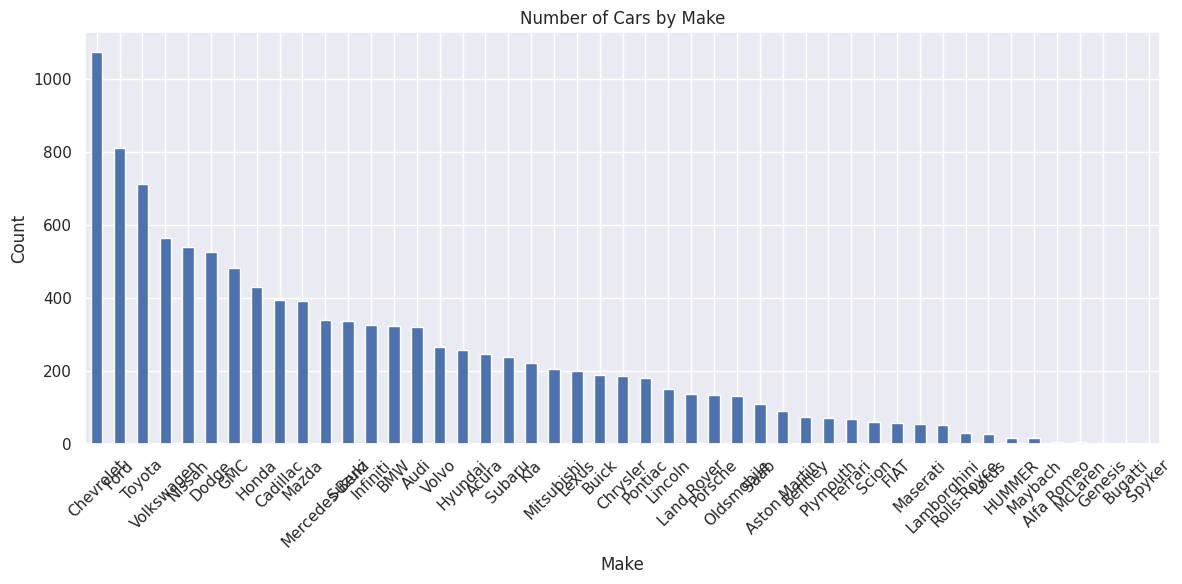

In [37]:
# Make a bar chart that displays how many times each brand of car appears in this data. 
make_counts = df['Make'].value_counts()

plt.figure(figsize=(12, 6))
make_counts.plot(kind='bar')
plt.title('Number of Cars by Make')
plt.xlabel('Make')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Make the cart more legible, by making it a horizontal bar chart and changing the figure size.  And also sort the values so the bar chart displays from lowest to highest.

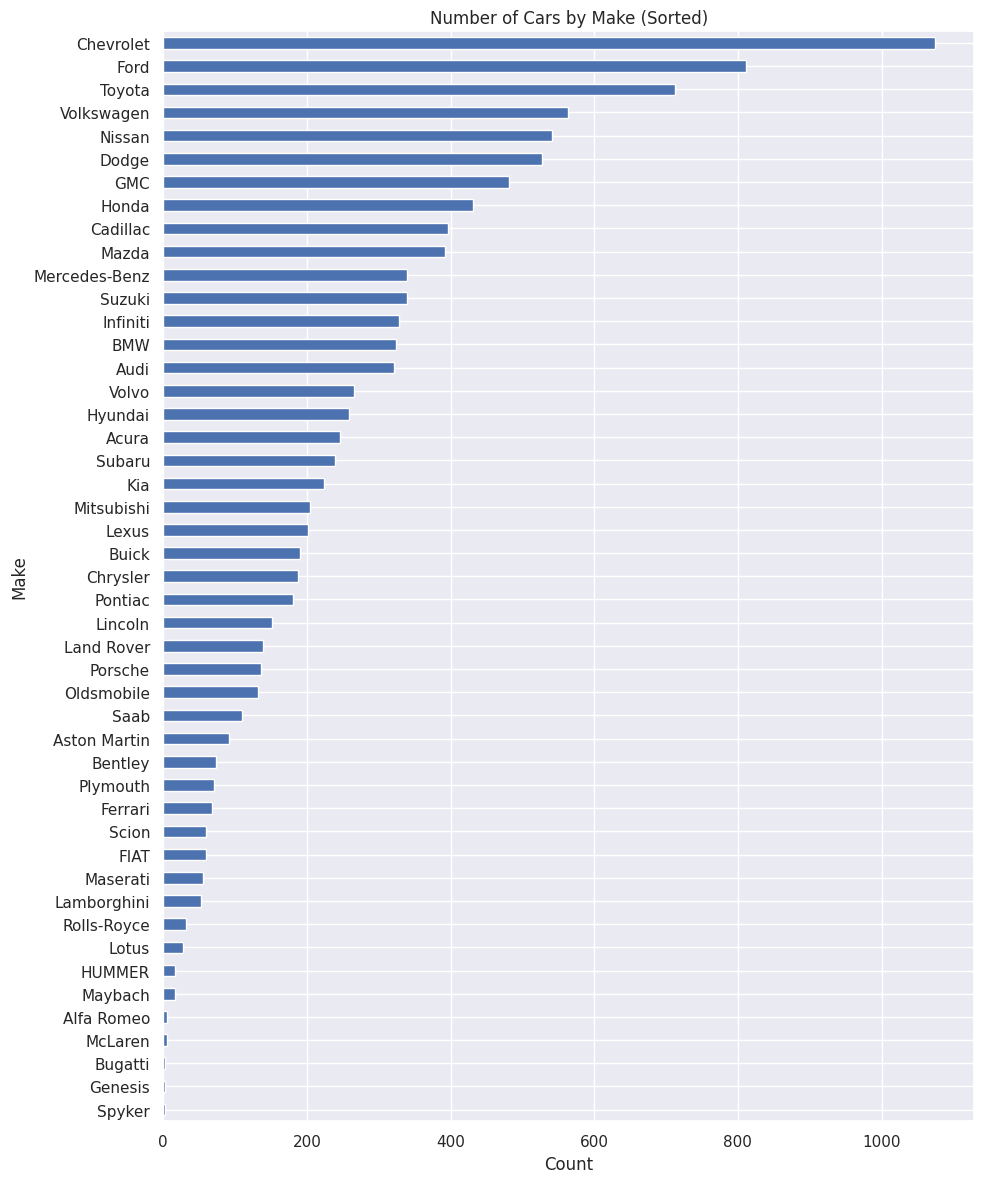

In [38]:
# Make the chart more legible, by making it a horizontal bar chart, sorting the values, and changing the figure size.
plt.figure(figsize=(10, 12))
make_counts.sort_values().plot(kind='barh')
plt.title('Number of Cars by Make (Sorted)')
plt.xlabel('Count')
plt.ylabel('Make')
plt.tight_layout()
plt.show()

# Make a timeline line chart in which the x-axis is the Year, and the y-axis is the mean MSRP.
* you're going to have to do a `groupby` for this one for sure. 
* What's noticeable about it and what do you think the error is...


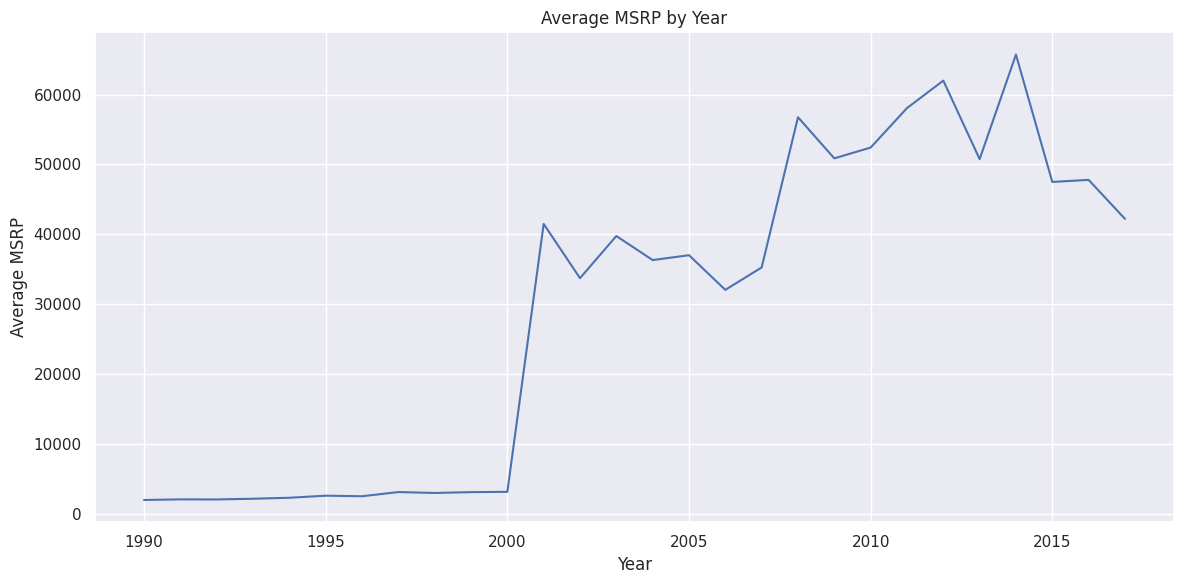

Notice the significant drop in prices around 2000, suggesting a data entry error.


In [39]:
# Make a timeline line chart in which the x-axis is the year, and the y-axis is the average MSRP.
yearly_msrp = df.groupby('Year')['MSRP'].mean()

plt.figure(figsize=(12, 6))
yearly_msrp.plot(kind='line')
plt.title('Average MSRP by Year')
plt.xlabel('Year')
plt.ylabel('Average MSRP')
plt.grid(True)
plt.tight_layout()
plt.show()

print("Notice the significant drop in prices around 2000, suggesting a data entry error.")

# It seems as though in the years before (and includig) 2000, they were counting in tens.
Make a new column that is called `adjusted_price`, that contains all prices, however, for every year before 2000 make it 10x the original MSRP.  
   * Hint; you might need to use our old friend `np.where`

In [40]:
# Make a column where is 10 when year is less than 2000, else 1.
df['price_adjuster'] = np.where(df['Year'] <= 2000, 10, 1)

# Multiply the MSRP by the price adjuster.
df['adjusted_price'] = df['MSRP'] * df['price_adjuster']

# Replot the new adjusted price.  
* Make the y-axis start at 0 and go up to 100,000

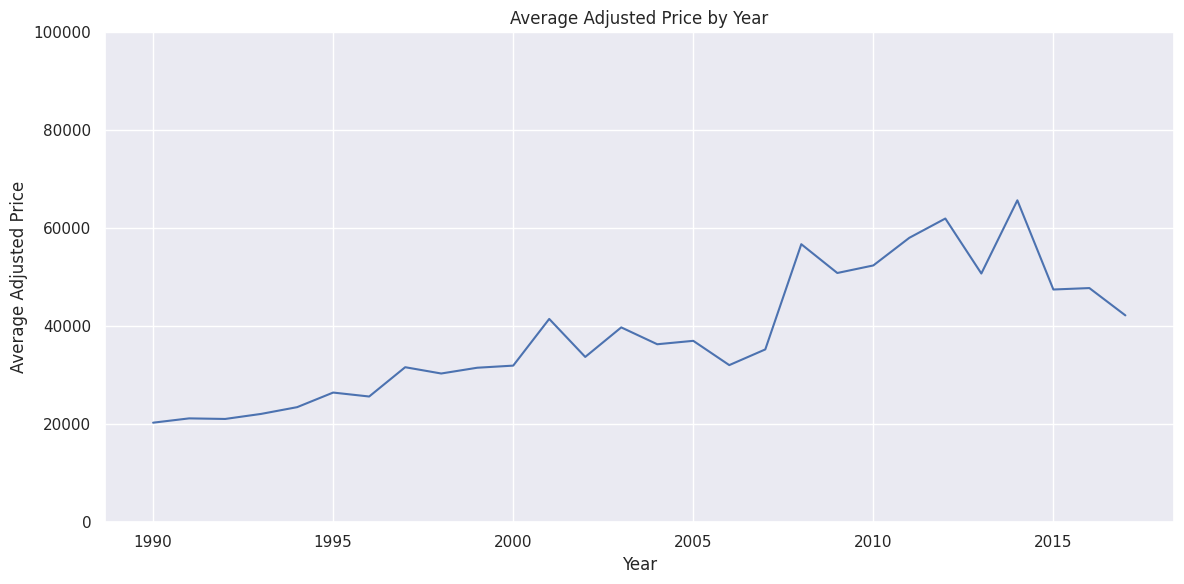

In [41]:
# Plot new prices
yearly_adjusted = df.groupby('Year')['adjusted_price'].mean()

plt.figure(figsize=(12, 6))
yearly_adjusted.plot(kind='line')
plt.title('Average Adjusted Price by Year')
plt.xlabel('Year')
plt.ylabel('Average Adjusted Price')
plt.ylim(0, 100000)
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot the relationship between Engine HP and highway MPG

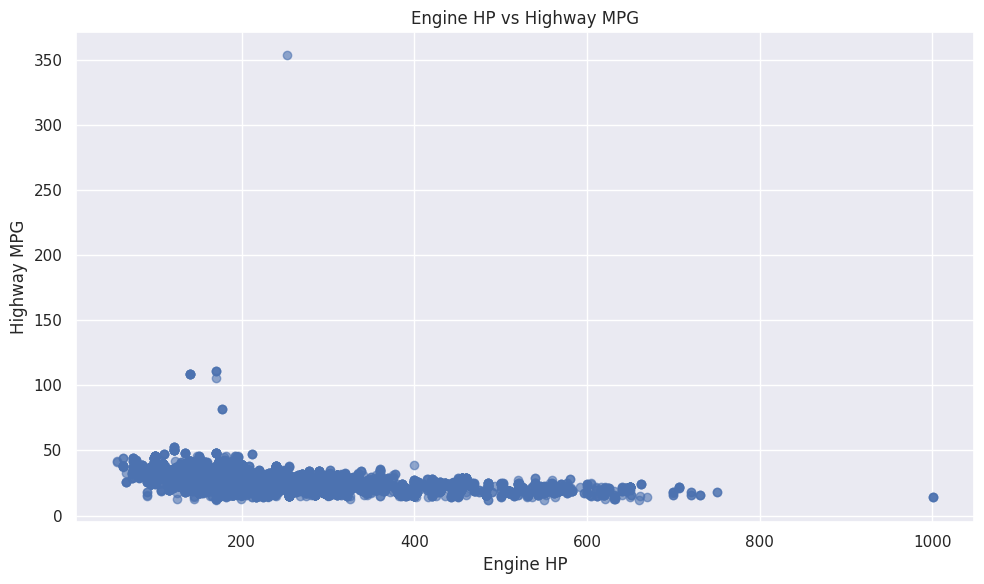

In [42]:
# Plot the relationship between Engine HP and highway MPG
plt.figure(figsize=(10, 6))
plt.scatter(df['Engine HP'], df['highway MPG'], alpha=0.6)
plt.title('Engine HP vs Highway MPG')
plt.xlabel('Engine HP')
plt.ylabel('Highway MPG')
plt.grid(True)
plt.tight_layout()
plt.show()

In [43]:
### IF WE DIDN'T GET TO REMOVING OUTLIERS IN CLASS, THEN YOU CAN SKIP THIS SECTION
# Remove any outliers from Engine HP and highway MPG 
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

df_clean = remove_outliers_iqr(df, 'Engine HP')
df_clean = remove_outliers_iqr(df_clean, 'highway MPG')

print(f"Original shape: {df.shape}, Cleaned shape: {df_clean.shape}")

Original shape: (11092, 17), Cleaned shape: (10462, 17)


# Replot the relationship between Engine HP and highway MPG


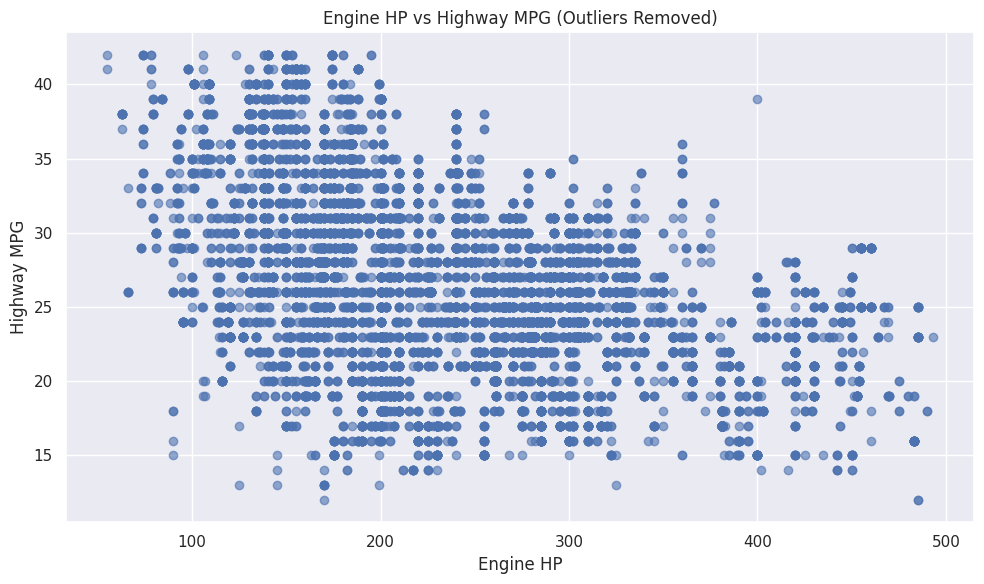

In [44]:
# Re-Plot the relationship between Engine HP and highway MPG
plt.figure(figsize=(10, 6))
plt.scatter(df_clean['Engine HP'], df_clean['highway MPG'], alpha=0.6)
plt.title('Engine HP vs Highway MPG (Outliers Removed)')
plt.xlabel('Engine HP')
plt.ylabel('Highway MPG')
plt.grid(True)
plt.tight_layout()
plt.show()

# Make a scatter plot of Engine HP vs highway MPG

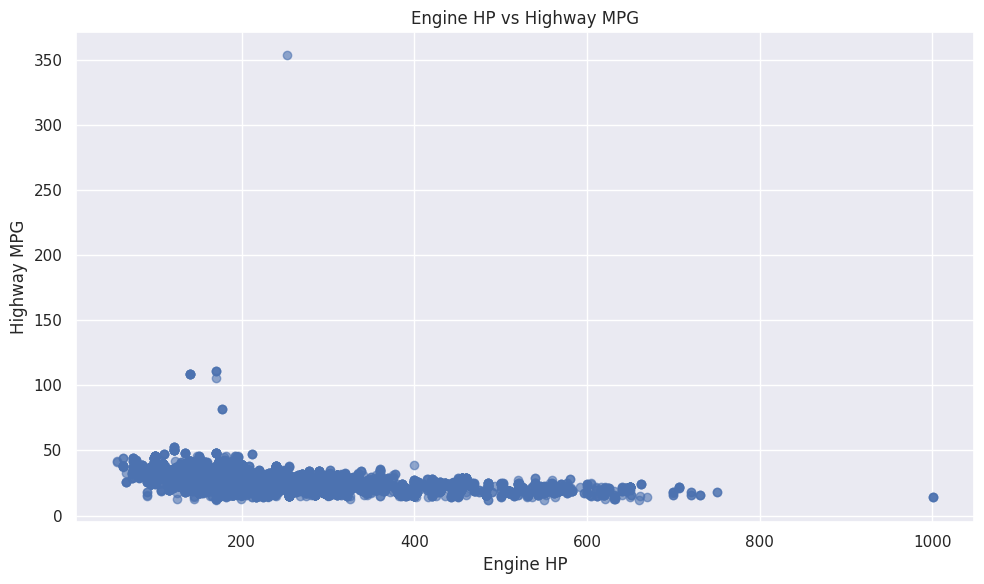

In [45]:
# Make a scatter plot of Engine HP vs highway MPG
plt.figure(figsize=(10, 6))
plt.scatter(df['Engine HP'], df['highway MPG'], alpha=0.6)
plt.title('Engine HP vs Highway MPG')
plt.xlabel('Engine HP')
plt.ylabel('Highway MPG')
plt.grid(True)
plt.tight_layout()
plt.show()

# What does this plot tell you about how Engine HP affects highway MPG?

In [46]:
# What does this plot tell you about how Engine HP affects highway MPG?
print('The scatter plot shows a negative correlation between Engine HP and highway MPG.')
print('As engine horsepower increases, highway miles per gallon tend to decrease.')
print('This makes sense because more powerful engines typically consume more fuel.')

The scatter plot shows a negative correlation between Engine HP and highway MPG.
As engine horsepower increases, highway miles per gallon tend to decrease.
This makes sense because more powerful engines typically consume more fuel.


# Using a pairplot, display all of the linear relationship.
* Which variables look like they have the strongest linear relationship (Besides MSRP and adjusted_price).

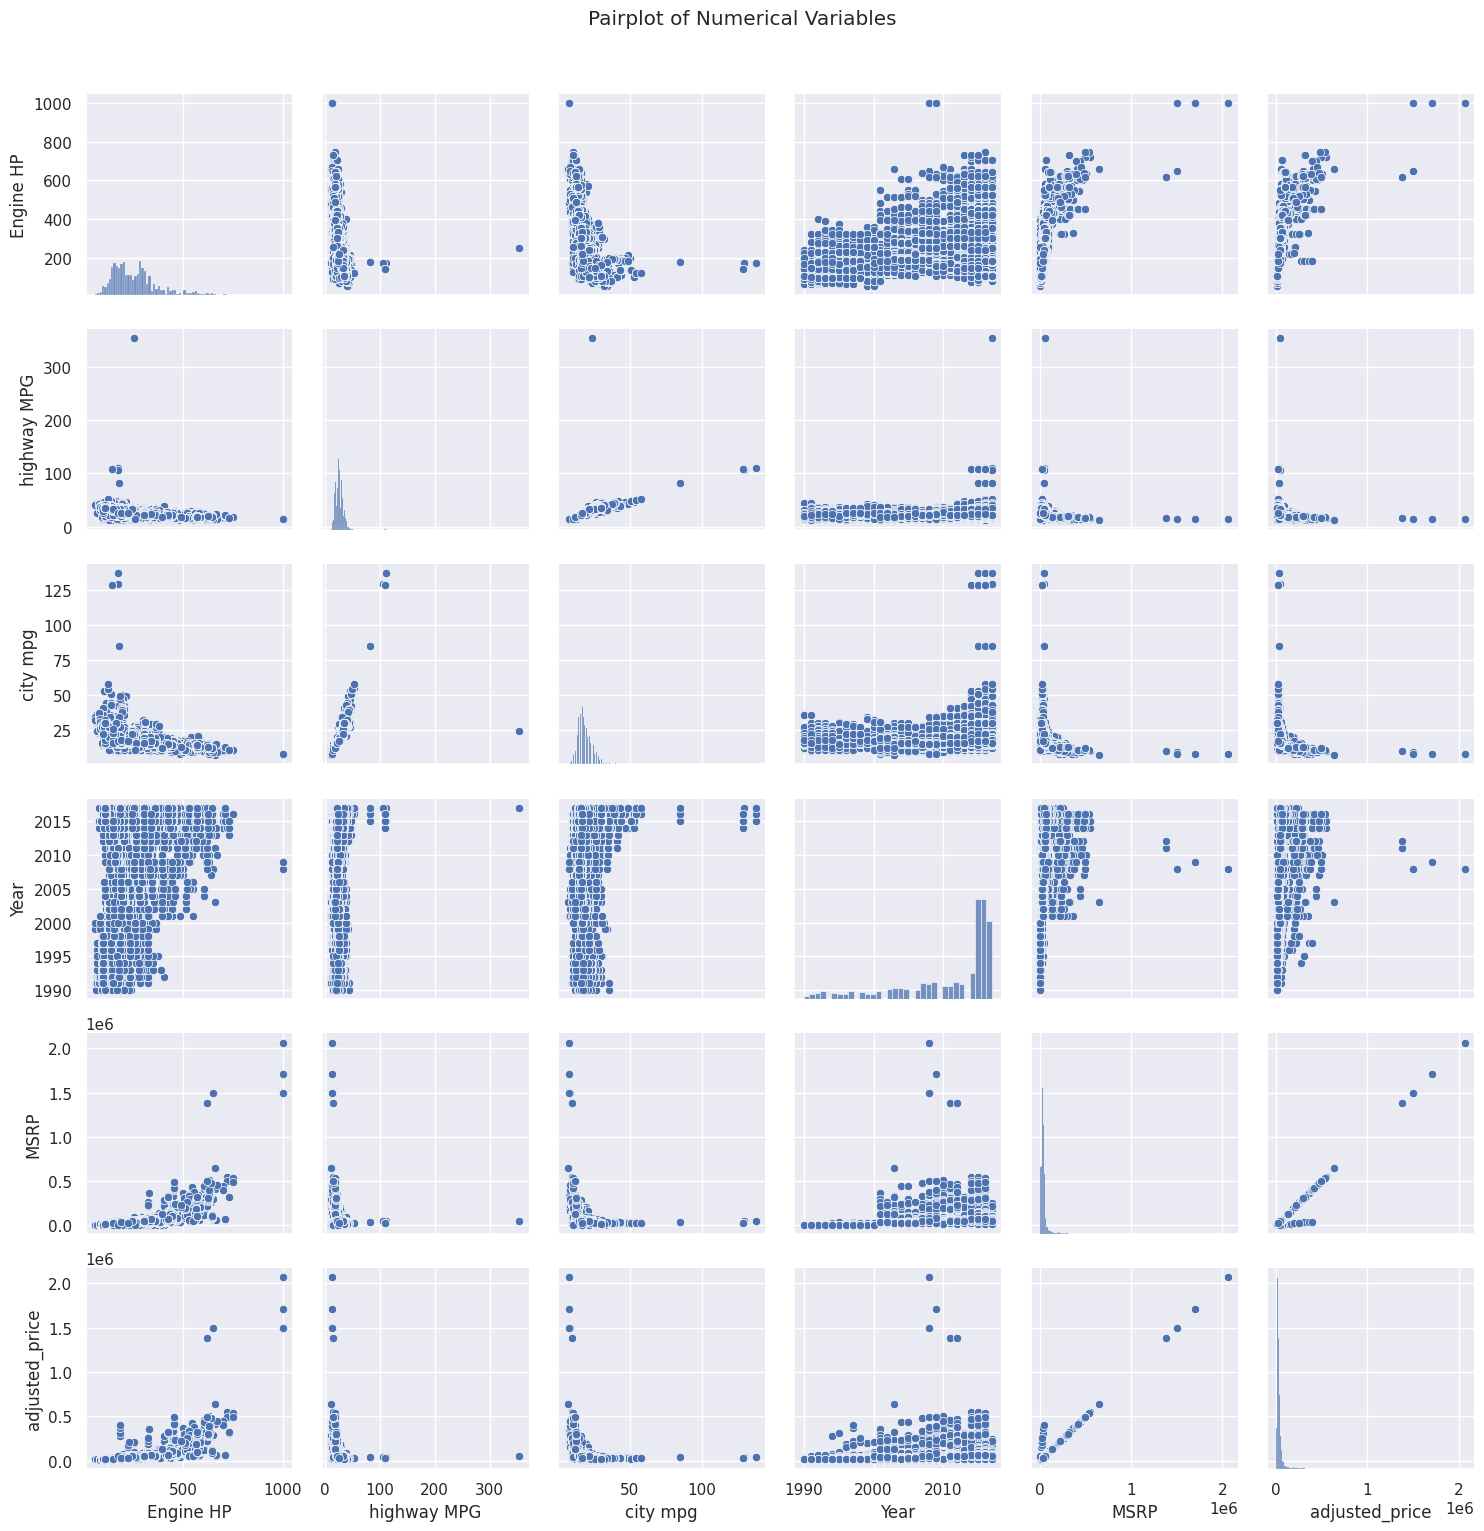

In [47]:
# Using a pairplot, display all of the linear relationship.
numerical_cols = ['Engine HP', 'highway MPG', 'city mpg', 'Year', 'MSRP', 'adjusted_price']
sns.pairplot(df[numerical_cols])
plt.suptitle('Pairplot of Numerical Variables', y=1.02)
plt.tight_layout()
plt.show()

In [48]:
# * Which variables look like they have the strongest linear relationship (Besides MSRP and adjusted_price).
print('From the pairplot, Engine HP and Year appear to have a strong positive relationship.')
print('Engine HP and city mpg/highway MPG show strong negative relationships.')
print('MSRP/adjusted_price and Engine HP also show a positive relationship.')

From the pairplot, Engine HP and Year appear to have a strong positive relationship.
Engine HP and city mpg/highway MPG show strong negative relationships.
MSRP/adjusted_price and Engine HP also show a positive relationship.


# Find which features actually have the strongest linear relationship using correlations.
* Make a heatmap plot of all of the correlations in our dataset.
* Change the figure size of our heatmap plot to be 8x8
* __Which feature does Engine HP have the strongest relationship with, and why do you think that relationship exists.__

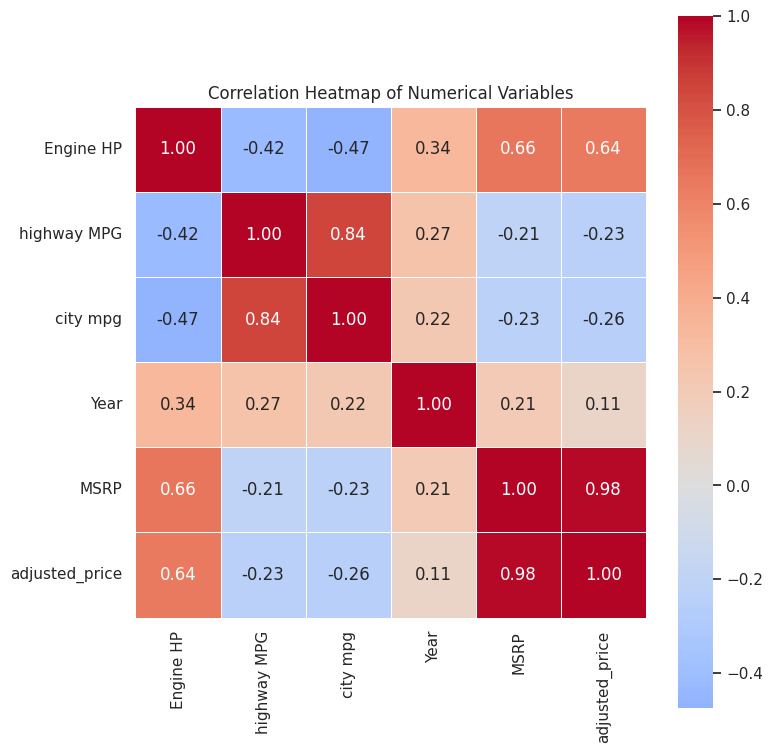

In [49]:
# * Make a heatmap plot of all of the correlations in our dataset.
# * Change the figure size of our heatmap plot to be 8x8
plt.figure(figsize=(8, 8))
correlation_matrix = df[numerical_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Variables')
plt.tight_layout()
plt.show()

In [50]:
# Which feature does Engine HP have the strongest relationship with, and why do you think that relationship exists.
engine_hp_corr = correlation_matrix['Engine HP'].drop('Engine HP')
strongest_corr_feature = engine_hp_corr.abs().idxmax()
strongest_corr_value = engine_hp_corr[strongest_corr_feature]

print(f"Engine HP has the strongest relationship with '{strongest_corr_feature}' (correlation: {strongest_corr_value:.3f})")
print('This relationship exists because MSRP typically increases with engine horsepower,')
print('as more powerful engines are more expensive to manufacture and are often')
print('featured in higher-end vehicle models.')

Engine HP has the strongest relationship with 'MSRP' (correlation: 0.659)
This relationship exists because MSRP typically increases with engine horsepower,
as more powerful engines are more expensive to manufacture and are often
featured in higher-end vehicle models.


# [EXTRA CREDIT] 
* (EASY) In the column names, replace all the spaces with an underscore, and make them all lowercase as well.

* (Easy) Learn more about cleaning data by following along in TA Georgios' tutorial in TA-Tips folder named `GI-Tips_1.ipynb`.

* (Medium) Do the same vizualizations using bokeh by following along in TA Stevens tutorial in the TA-Tips folder named `SS-Tips.ipynb`.


* (Medium) Learn how to remove outliers properly by following along in TA Georgios' tutorial in TA-Tips folder named `GI-Tips_2.ipynb`.

* (Variable) Complete one or more of the [Extra-Extra credit](https://docs.google.com/document/d/1D99fY13cF3kzIiJILZ3fwzhOF73z_xPBNxxweMpBkOY/edit) items. 




In [51]:

df.columns = [col.replace(' ', '_').lower() for col in df.columns]
print("Updated column names:", df.columns.tolist())

Updated column names: ['make', 'model', 'year', 'engine_fuel_type', 'engine_hp', 'engine_cylinders', 'transmission_type', 'driven_wheels', 'number_of_doors', 'vehicle_size', 'vehicle_style', 'highway_mpg', 'city_mpg', 'popularity', 'msrp', 'price_adjuster', 'adjusted_price']
